# Kütüphanelerin yüklenmesi

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

# Verinin Okunması ve Genel Bilgilerin İncelenmesi
TripAdvisor kullanıcı değerlendirme verisi okunur, satır/sütun sayısı (shape) yazdırılır ve değişken tipleri incelenir.

In [ ]:
df = pd.read_csv("/content/sample_data/tripadvisor_review.csv")
print(f"Veri boyutu: {df.shape}")
df.info()

Veri boyutu: (980, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User ID      980 non-null    object 
 1   Category 1   980 non-null    float64
 2   Category 2   980 non-null    float64
 3   Category 3   980 non-null    float64
 4   Category 4   980 non-null    float64
 5   Category 5   980 non-null    float64
 6   Category 6   980 non-null    float64
 7   Category 7   980 non-null    float64
 8   Category 8   980 non-null    float64
 9   Category 9   980 non-null    float64
 10  Category 10  980 non-null    float64
dtypes: float64(10), object(1)
memory usage: 84.3+ KB


In [ ]:
# Eksik değer kontrolü
df.isnull().sum()

,0
User ID,0
Category 1,0
Category 2,0
Category 3,0
Category 4,0
Category 5,0
Category 6,0
Category 7,0
Category 8,0
Category 9,0


In [ ]:
# Sayısal değişkenlerin özeti
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Category 1,980.0,0.893194,0.326912,0.34,0.67,0.83,1.0200,3.22
Category 2,980.0,1.352612,0.478280,0.00,1.08,1.28,1.5600,3.64
Category 3,980.0,1.013306,0.788607,0.13,0.27,0.82,1.5725,3.62
Category 4,980.0,0.532500,0.279731,0.15,0.41,0.50,0.5800,3.44
Category 5,980.0,0.939735,0.437430,0.06,0.64,0.90,1.2000,3.30
Category 6,980.0,1.842898,0.539538,0.14,1.46,1.80,2.2000,3.76
Category 7,980.0,3.180939,0.007824,3.16,3.18,3.18,3.1800,3.21
Category 8,980.0,2.835061,0.137505,2.42,2.74,2.82,2.9100,3.39
Category 9,980.0,1.569439,0.364629,0.74,1.31,1.54,1.7600,3.17
Category 10,980.0,2.799224,0.321380,2.14,2.54,2.78,3.0400,3.66


In [ ]:
df.head(2)

,User ID,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32


# Kullanıcı ID'sinin İndekse Alınması ve Eksik Veri Tamamlama
User ID sütunu analize sayısal özellik olarak girmemesi için satır indeksi yapılır. SimpleImputer ile olası eksik değerler sütun ortalamasıyla doldurulur.

In [ ]:
df.set_index("User ID", inplace=True)
imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(
    imputer.fit_transform(df), columns=df.columns, index=df.index
)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")

Eksik deger kaldi mi: 0


# Özelliklerin Standartlaştırılması (StandardScaler)
Mesafe tabanlı kümeleme algoritmalarının tüm kategorilere eşit ağırlık vermesi için veriler ortalaması 0, standart sapması 1 olacak biçimde ölçeklendirilir.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)
df_scaled = pd.DataFrame(
    X_scaled, columns=df_imputed.columns, index=df_imputed.index
)
df_scaled.head(2)

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
User ID,,,,,,,,,,
User 1,0.112645,0.935887,1.619750,0.312960,-0.319608,1.070169,1.158657,-0.327872,0.687518,-1.180591
User 2,0.388088,1.772644,2.089171,0.384494,1.098486,2.479500,3.716053,-1.492056,0.797274,-1.491908


# Optimum Küme Sayısının Belirlenmesi

(Elbow ve Silhouette Analizi)$K=2$ ile $10$ arasındaki küme sayıları için K-Means çalıştırılarak WCSS (Inertia) ve Silhouette skorları hesaplanır, grafik üzerinde optimum nokta tespit edilir.

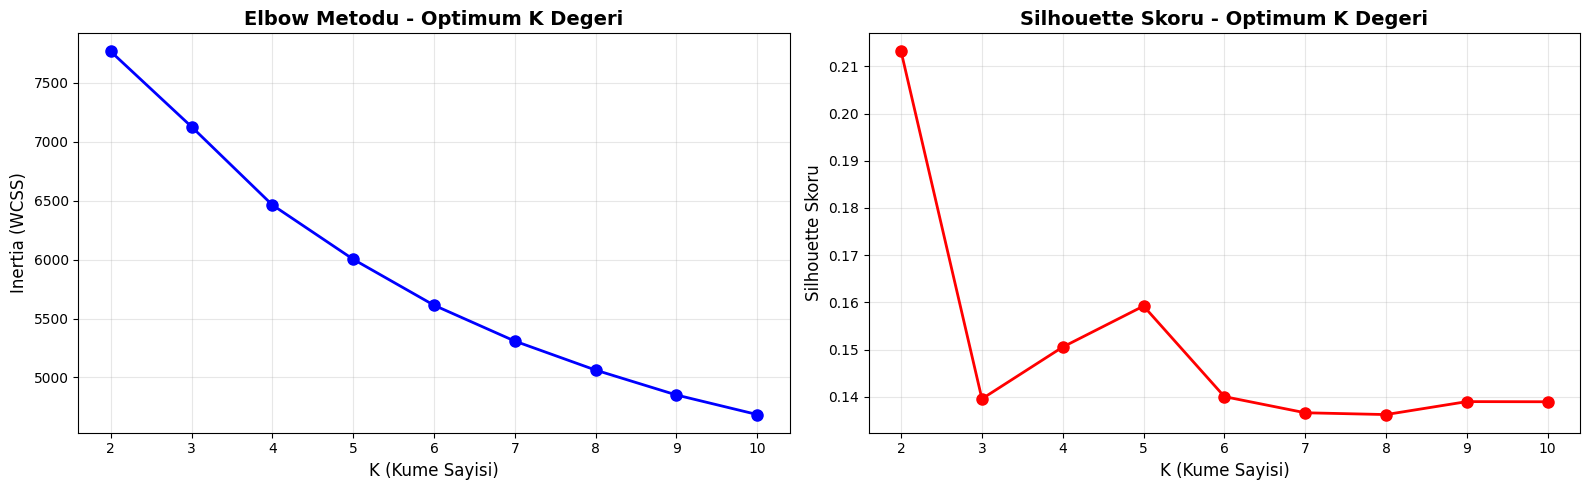

En iyi silhoutte skoru: 0.2132
Optimum K degeri: 2


In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  inertia.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, "bo-", linewidth=2, markersize=8)
axes[0].set_title(
    "Elbow Metodu - Optimum K Degeri", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("K (Kume Sayisi)", fontsize=12)
axes[0].set_ylabel("Inertia (WCSS)", fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title(
    "Silhouette Skoru - Optimum K Degeri", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("K (Kume Sayisi)", fontsize=12)
axes[1].set_ylabel("Silhouette Skoru", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"En iyi silhoutte skoru: {max(silhouette_scores):.4f}")
print(f"Optimum K degeri: {optimal_k}")

# K-Means Modeli Eğitimi ve Kümeleme

Başarım MetrikleriEn yüksek skoru veren optimum $K$ değeriyle K-Means modeli eğitilir; Silhouette, Davies-Bouldin, Calinski-Harabasz metrikleri ve kullanıcıların kümelere dağılımı yazdırılır.  

In [ ]:
optimal_k = K_range[
    np.argmax(silhouette_scores)
]  # Elbow ve silhouette analizine gore (TripAdvisor icin k=2)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Kumeleme Sonuclari:")
print(f"Kume sayisi: {optimal_k}")
print(f"Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(
    f"Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}"
)
print(
    "Calinski-Harabasz Skoru:"
    f" {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}"
)
print("\nKume dagilimi:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 2
Silhouette Skoru: 0.2132
Davies-Bouldin Indeksi: 1.7957
Calinski-Harabasz Skoru: 255.9265

Kume dagilimi:
0    606
1    374
Name: count, dtype: int64


# PCA ile 2 Boyutlu Küme Görselleştirmesi

10 boyutlu kategori uzayı Temel Bileşen Analizi (PCA) ile 2 boyuta indirgenir ve kullanıcı kümeleri saçılım grafiğinde renklendirilerek çizdirilir.

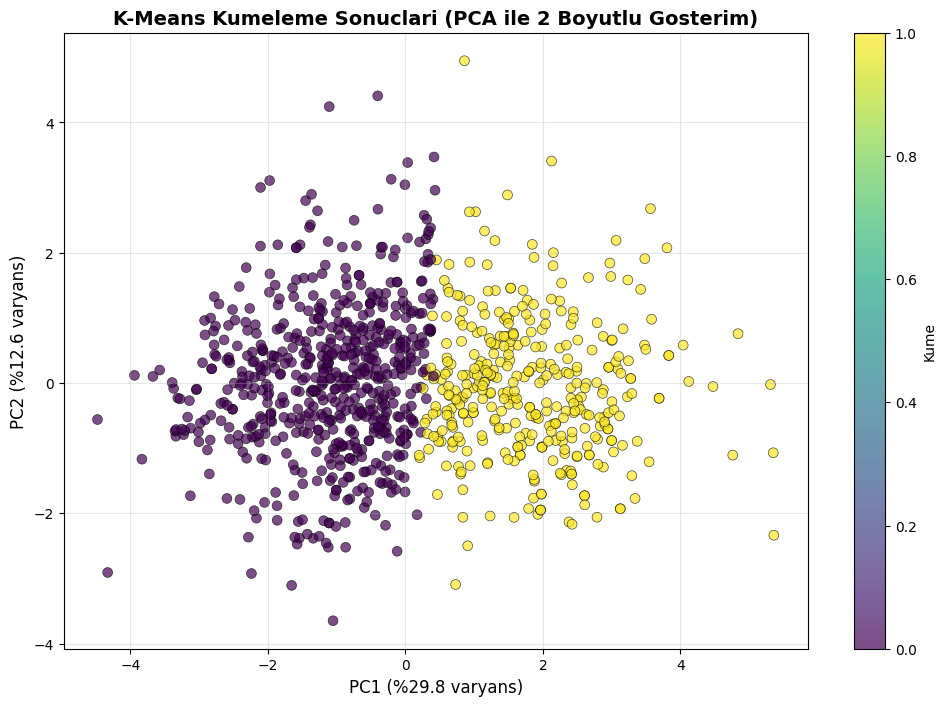

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.7,
    s=50,
    edgecolors="k",
    linewidth=0.5,
)
plt.colorbar(scatter, label="Kume")
plt.title(
    "K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel(
    f"PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)", fontsize=12
)
plt.ylabel(
    f"PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)", fontsize=12
)
plt.grid(True, alpha=0.3)
plt.show()

# Hiyerarşik Kümeleme ve Dendrogram Çizimi

Ward bağlantı yöntemi ve Öklid mesafesi kullanılarak ilk 200 kullanıcı örneği üzerinden hiyerarşik kümeleme dendrogramı oluşturulur.

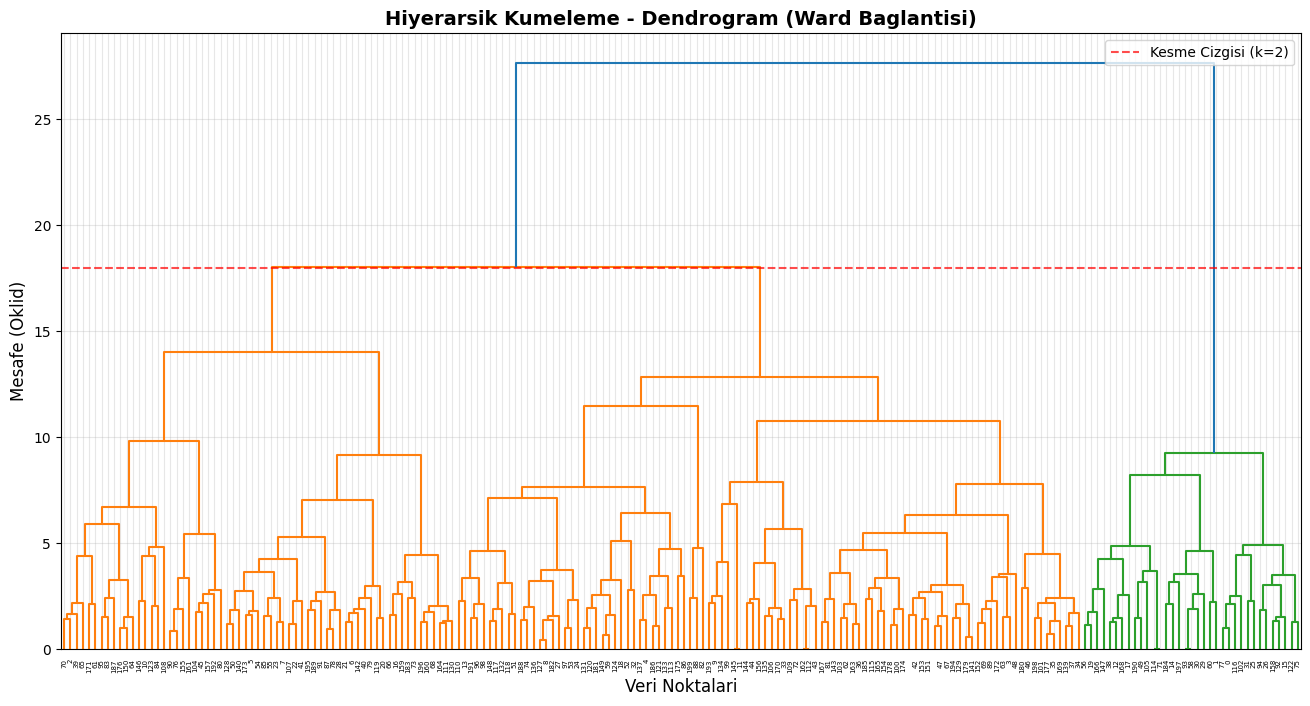

In [ ]:
plt.figure(figsize=(16, 8))
linked = linkage(
    X_scaled[:200], method="ward"
)  # Gorsellestirme icin ilk 200 ornek
dendrogram(
    linked,
    orientation="top",
    distance_sort="descending",
    show_leaf_counts=False,
    truncate_mode="level",
    p=10,
)
plt.title(
    "Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Veri Noktalari", fontsize=12)
plt.ylabel("Mesafe (Oklid)", fontsize=12)
plt.axhline(
    y=18, color="r", linestyle="--", alpha=0.7, label="Kesme Cizgisi (k=2)"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 2
Baglanti yontemi: ward
Silhouette Skoru: 0.1820
Davies-Bouldin Indeksi: 1.9895
Calinski-Harabasz Skoru: 203.9549

Kume dagilimi:
0    360
1    620
Name: count, dtype: int64


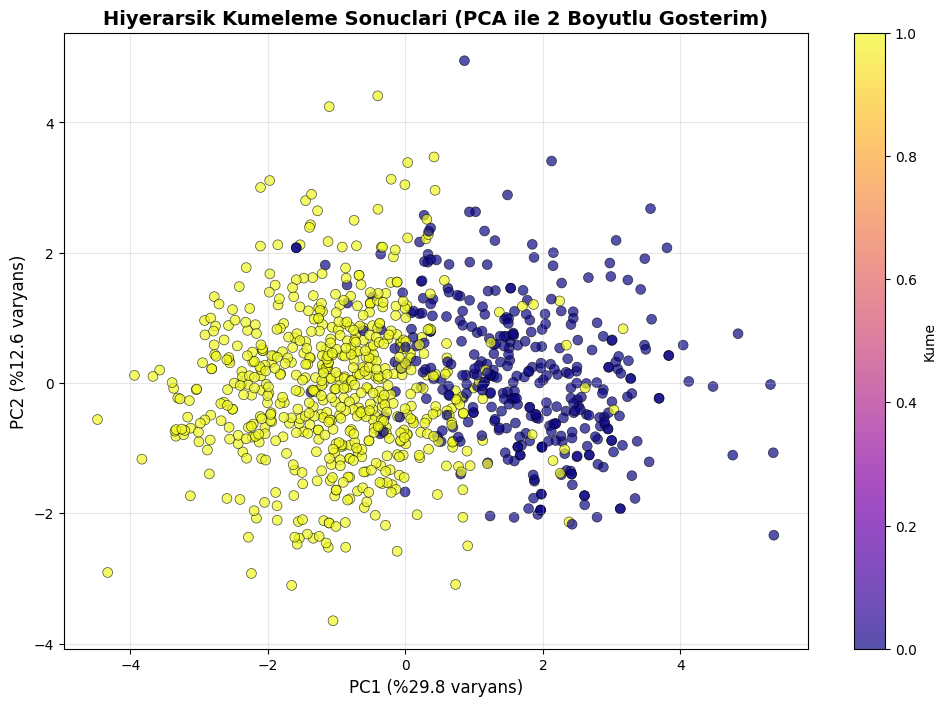

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

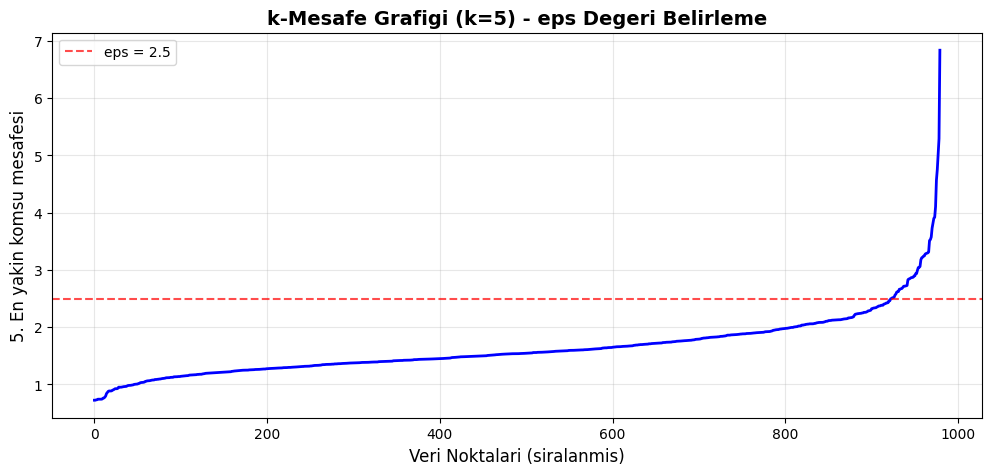

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 2.5, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Kumeleme Sonuclari:
eps: 2.5, min_samples: 5
Olusan kume sayisi: 1
Gurultu (aykiri deger) sayisi: 31
Gurultu orani: 3.16%

Kume dagilimi:
-1     31
 0    949
Name: count, dtype: int64


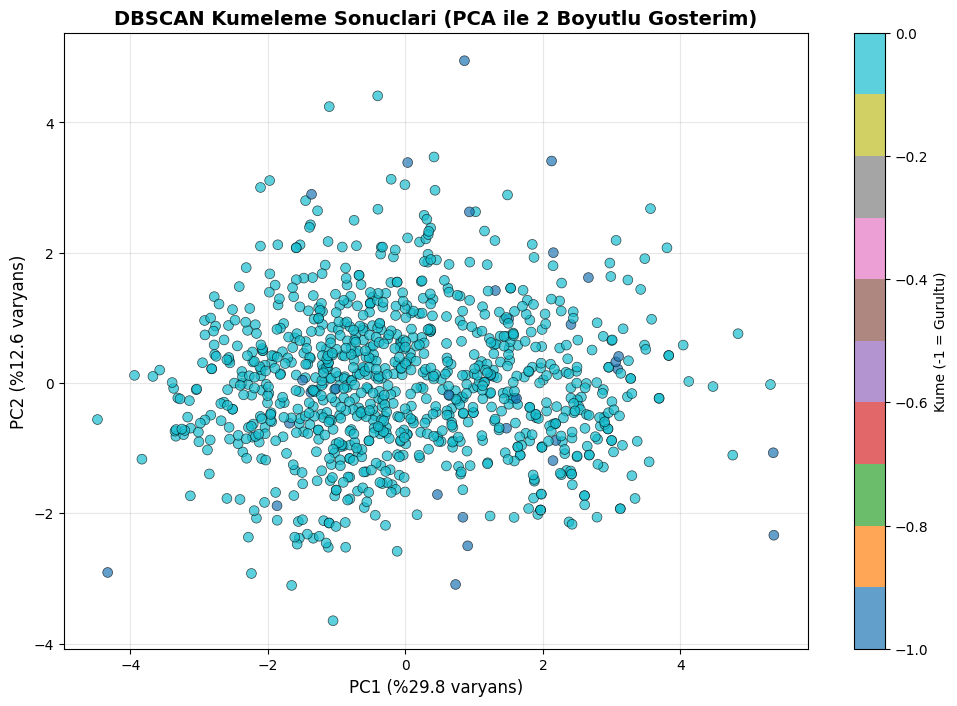

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Decision Tree

--- Decision Tree Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        59
           1       0.94      0.81      0.87        62
           2       0.69      0.81      0.75        75

    accuracy                           0.75       196
   macro avg       0.76      0.74      0.75       196
weighted avg       0.76      0.75      0.75       196



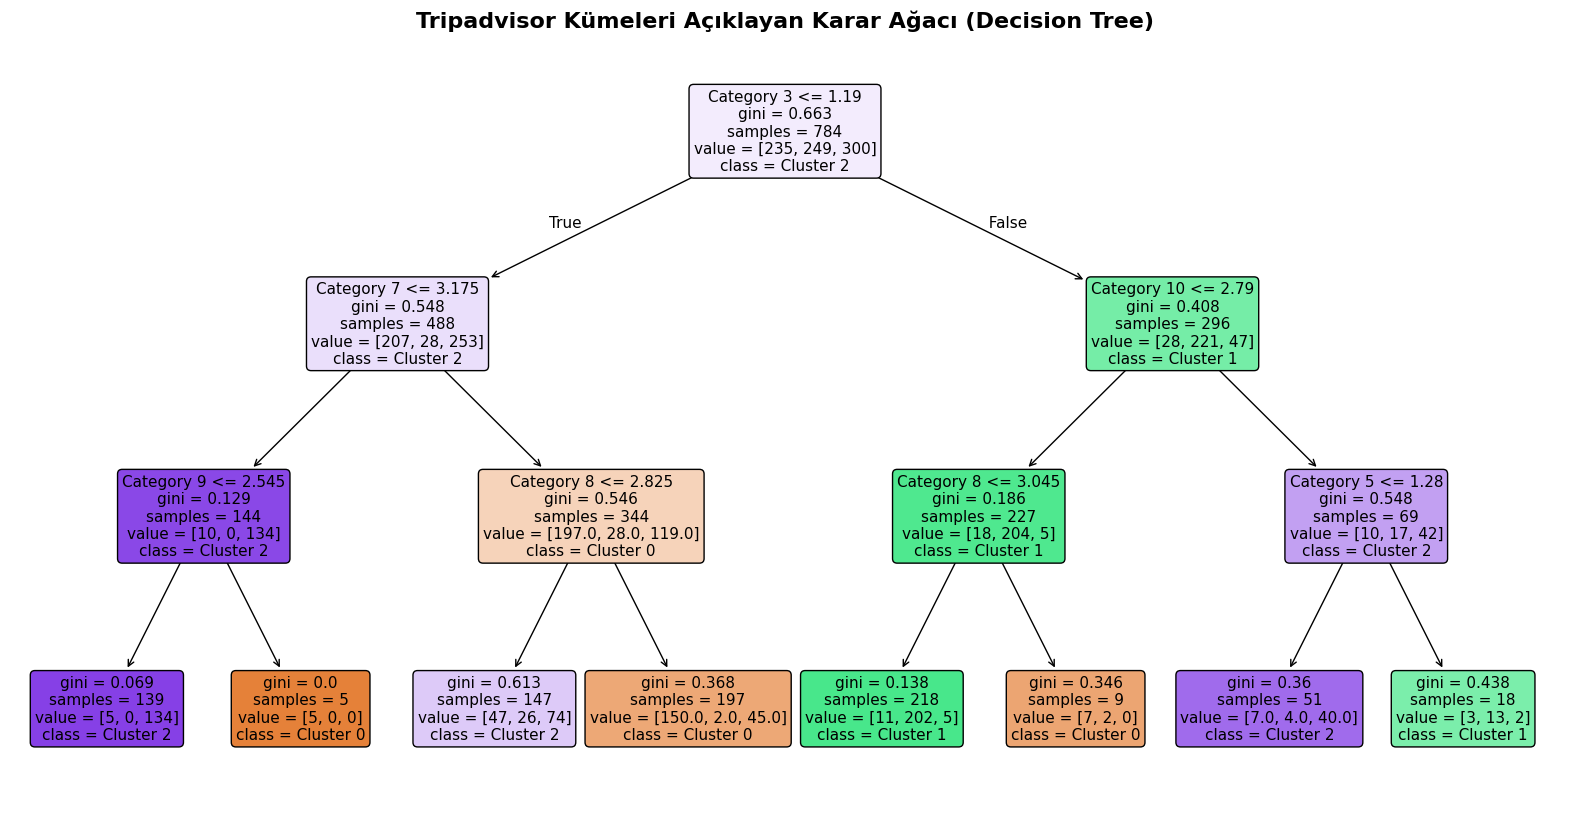

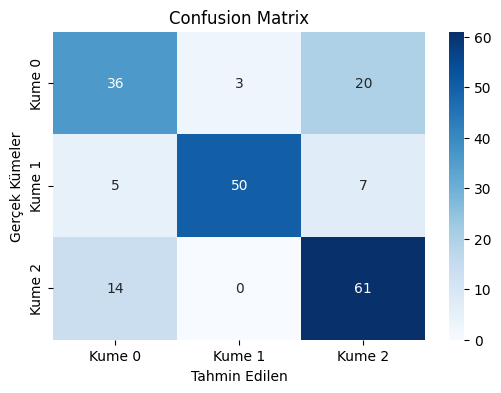

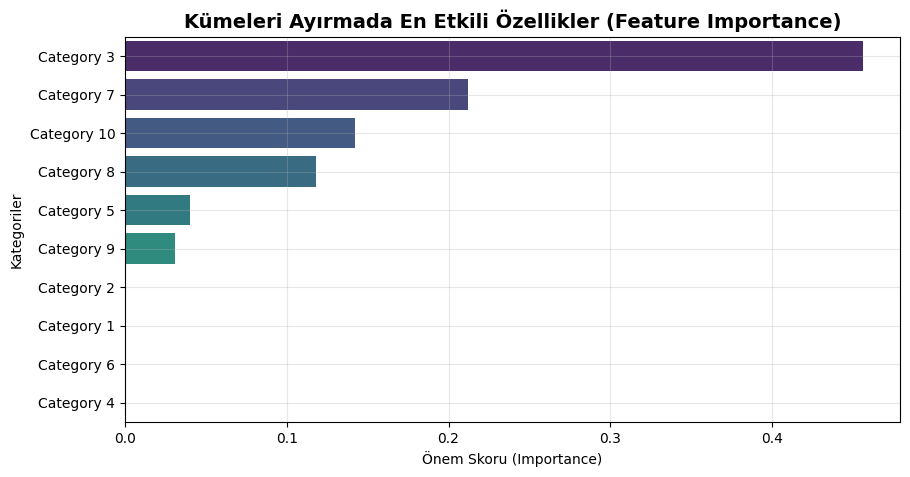


--- Kümelerin Kategorilere Göre Ortalama Puanları ---
Cluster             0         1         2
Category 1   0.892585  0.894920  0.892240
Category 2   1.170340  1.528489  1.349653
Category 3   0.635816  1.841961  0.622027
Category 4   0.565238  0.641029  0.416827
Category 5   0.914898  1.248489  0.703147
Category 6   1.919048  2.240064  1.453813
Category 7   3.180238  3.188424  3.175280
Category 8   2.923537  2.784373  2.807733
Category 9   1.784218  1.537781  1.427307
Category 10  2.735816  2.527717  3.074107


In [ ]:
# ==========================================
# 1. GEREKLİ KÜTÜPHANELER
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ==========================================
# 2. VERİYİ YÜKLEME VE ÖN İŞLEME
# ==========================================
# TripAdvisor veri setini okuma
df_trip = pd.read_csv("/content/sample_data/tripadvisor_review.csv")

# 'User ID' sütununu indeks olarak ayarlama
if 'User ID' in df_trip.columns:
    df_trip.set_index('User ID', inplace=True)

# Özellik isimleri (Category 1 - Category 10)
feature_names = df_trip.columns.tolist()

# Veriyi standartlaştırma
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_trip)

# ==========================================
# 3. K-MEANS KÜMELEME (Hedef Etiketleri Oluşturma)
# ==========================================
# Optimum küme sayısı (örnek analiz için k=3 seçilmiştir)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Orijinal veriye kümeleri ekleme
df_trip['Cluster'] = cluster_labels

# ==========================================
# 4. DECISION TREE (KARAR AĞACI) SINIFLANDIRICISI
# ==========================================
# Bağımsız değişkenler (X) ve Kümelerden gelen bağımlı değişken (y)
X = df_trip[feature_names]
y = df_trip['Cluster']

# Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree modelini tanımlama ve eğitme
# (Yorumlanabilirliği artırmak adına max_depth=3 veya 4 seçilir)
dt_model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)

# Model Tahminleri
y_pred = dt_model.predict(X_test)

# ==========================================
# 5. DECISION TREE DEĞERLENDİRME VE GÖRSELLEŞTİRME
# ==========================================
print("--- Decision Tree Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

# Karar Ağacını Görselleştirme
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=[f'Cluster {i}' for i in range(optimal_k)],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Tripadvisor Kümeleri Açıklayan Karar Ağacı (Decision Tree)", fontsize=16, fontweight='bold')
plt.show()

# Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Kume {i}' for i in range(optimal_k)],
            yticklabels=[f'Kume {i}' for i in range(optimal_k)])
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Kümeler")
plt.show()

# ==========================================
# 6. DECISION TREE SONRASI: ÖZELLİK ÖNEM DÜZEYLERİ (Feature Importance)
# ==========================================
importances = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Kümeleri Ayırmada En Etkili Özellikler (Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Önem Skoru (Importance)")
plt.ylabel("Kategoriler")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 7. KÜME PROFİL ANALİZİ (Cluster Profiling)
# ==========================================
print("\n--- Kümelerin Kategorilere Göre Ortalama Puanları ---")
cluster_summary = df_trip.groupby('Cluster')[feature_names].mean().T
print(cluster_summary)